In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/boston-house-prices/housing.csv


In [102]:
import plotly.express as px
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder, OrdinalEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression
import warnings

warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)


Content
Each record in the database describes a Boston suburb or town. The data was drawn from the Boston Standard Metropolitan Statistical Area (SMSA) in 1970. The attributes are deﬁned as follows (taken from the UCI Machine Learning Repository1): 

CRIM: per capita crime rate by town

ZN: proportion of residential land zoned for lots over 25,000 sq.ft.

INDUS: proportion of non-retail business acres per town

CHAS: Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)

NOX: nitric oxides concentration (parts per 10 million)

RM: average number of rooms per dwelling

AGE: proportion of owner-occupied units built prior to 1940

DIS: weighted distances to ﬁve Boston employment centers

RAD: index of accessibility to radial highways

TAX: full-value property-tax rate per $10,000

PTRATIO: pupil-teacher ratio by town 

MEDV: Median value of owner-occupied homes in $1000s

B: 1000(Bk−0.63)

LSTAT: % lower status of the population


We can see that the input attributes have a mixture of units.

In [6]:
df=pd.read_csv("/kaggle/input/boston-house-prices/housing.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 1 columns):
 #   Column                                                                                            Non-Null Count  Dtype 
---  ------                                                                                            --------------  ----- 
 0    0.00632  18.00   2.310  0  0.5380  6.5750  65.20  4.0900   1  296.0  15.30 396.90   4.98  24.00  505 non-null    object
dtypes: object(1)
memory usage: 4.1+ KB


In [7]:
df.head()

,0.00632 18.00 2.310 0 0.5380 6.5750 65.20 4.0900 1 296.0 15.30 396.90 4.98 24.00
0,0.02731 0.00 7.070 0 0.4690 6.4210 78...
1,0.02729 0.00 7.070 0 0.4690 7.1850 61...
2,0.03237 0.00 2.180 0 0.4580 6.9980 45...
3,0.06905 0.00 2.180 0 0.4580 7.1470 54...
4,0.02985 0.00 2.180 0 0.4580 6.4300 58...


In [8]:
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
df = pd.read_csv('/kaggle/input/boston-house-prices/housing.csv', header=None, delimiter=r"\s+", names=column_names)
'''
By default, pd.read_csv assumes the first row is a header. Setting header=None means the first row is treated as data, and column names must be provided elsewhere (via the names parameter).
'''
'''
The delimiter parameter specifies how values in the CSV file are separated.
The value r"\s+" is a regular expression that matches one or more whitespace characters (spaces, tabs, etc.).
'''
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [9]:
print("Dataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB
None


In [10]:
print("\nSummary Statistics:")
df.describe()


Summary Statistics:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [11]:
df[df.duplicated()]

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV


In [12]:
df[df.isnull().any(axis=1)]

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV


In [58]:
target_features = ['MEDV']

continuous_features = ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 
                          'TAX', 'PTRATIO', 'B', 'LSTAT']

categorical_features = ['CHAS']
ordinal_features = ['RAD']

In [59]:
def outlier_percent(df,numeric_col):
    for c in numeric_col:
        col = df[c].dropna()  
        q1 = col.quantile(0.25)
        q3 = col.quantile(0.75)
        iqr = q3 - q1 #Interquartile range
        fence_low  = q1-1.5*iqr
        fence_high = q3+1.5*iqr
        lower_out = len(col[(col < fence_low)])
        upper_out = len(col[(col > fence_high)])
        outlier_count = upper_out+lower_out
        prop_out = outlier_count/len(df[c])
        print(c, ": "+"{:.2%}".format(prop_out))

outlier_percent(df,continuous_features+target_features )

CRIM : 13.04%
ZN : 13.44%
INDUS : 0.00%
NOX : 0.00%
RM : 5.93%
AGE : 0.00%
DIS : 0.99%
TAX : 0.00%
PTRATIO : 2.96%
B : 15.22%
LSTAT : 1.38%
MEDV : 7.91%


In [60]:
def show_dist(df,numeric_col):
    row_n=int(np.sqrt(len(numeric_col)))+1
    df[numeric_col].plot(kind='kde', subplots=True, layout=(row_n,row_n), figsize=(15, 10), sharex=False)
    plt.suptitle("KDE Plots of Numeric Columns", fontsize=16)
    plt.tight_layout()
    plt.show()

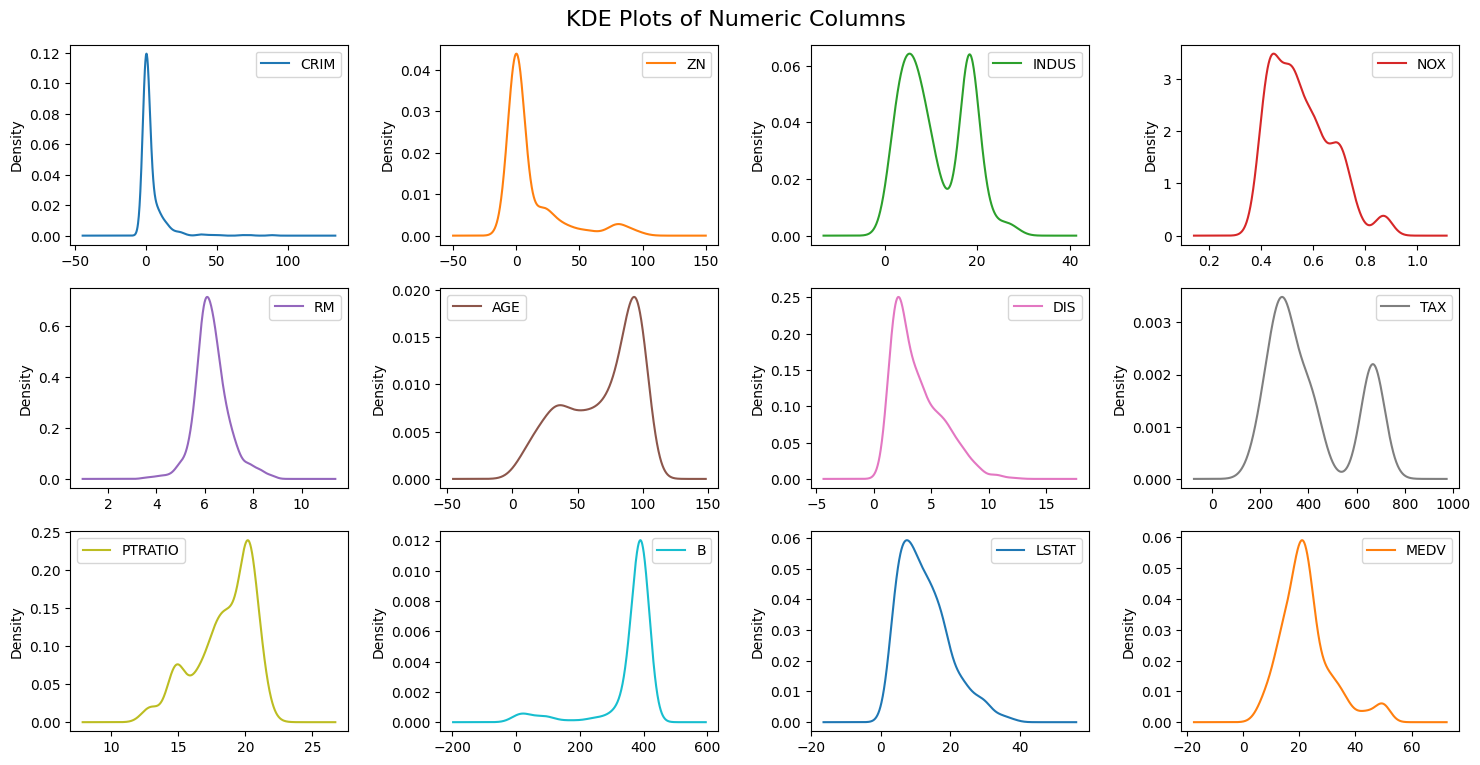

In [61]:
#numeric_col=df.select_dtypes(include=np.number).columns.tolist()
numeric_col=continuous_features+target_features 
show_dist(df,numeric_col)

In [62]:
df[numeric_col].skew()

CRIM       5.223149
ZN         2.225666
INDUS      0.295022
NOX        0.729308
RM         0.403612
AGE       -0.598963
DIS        1.011781
TAX        0.669956
PTRATIO   -0.802325
B         -2.890374
LSTAT      0.906460
MEDV       1.108098
dtype: float64

In [78]:
df_tran = df.copy()
log_numeric_col = []
sqrt_numeric_col = []
og_numeric_col=continuous_features+target_features
numeric_col=continuous_features+target_features

for col in numeric_col:
    skewness = df_tran[col].skew()
    
    if skewness >= 1 or skewness <= -1:
        print(col)
        # === Log & Sqrt ===
        df_tran[f'log_{col}'] = np.log1p(df_tran[col])
        df_tran[f'sqrt_{col}'] = np.sqrt(df_tran[col])
        log_numeric_col.append(f'log_{col}')
        sqrt_numeric_col.append(f'sqrt_{col}')
    else:
        log_numeric_col.append(col)
        sqrt_numeric_col.append(col)

CRIM
ZN
DIS
B
MEDV


In [86]:
numeric_col+=list(set(log_numeric_col+sqrt_numeric_col))
numeric_col=list(set(numeric_col))
numeric_col

['sqrt_MEDV',
 'B',
 'NOX',
 'PTRATIO',
 'LSTAT',
 'log_CRIM',
 'ZN',
 'log_MEDV',
 'sqrt_ZN',
 'INDUS',
 'RM',
 'DIS',
 'log_ZN',
 'log_B',
 'MEDV',
 'sqrt_B',
 'AGE',
 'sqrt_DIS',
 'sqrt_CRIM',
 'TAX',
 'CRIM',
 'log_DIS']

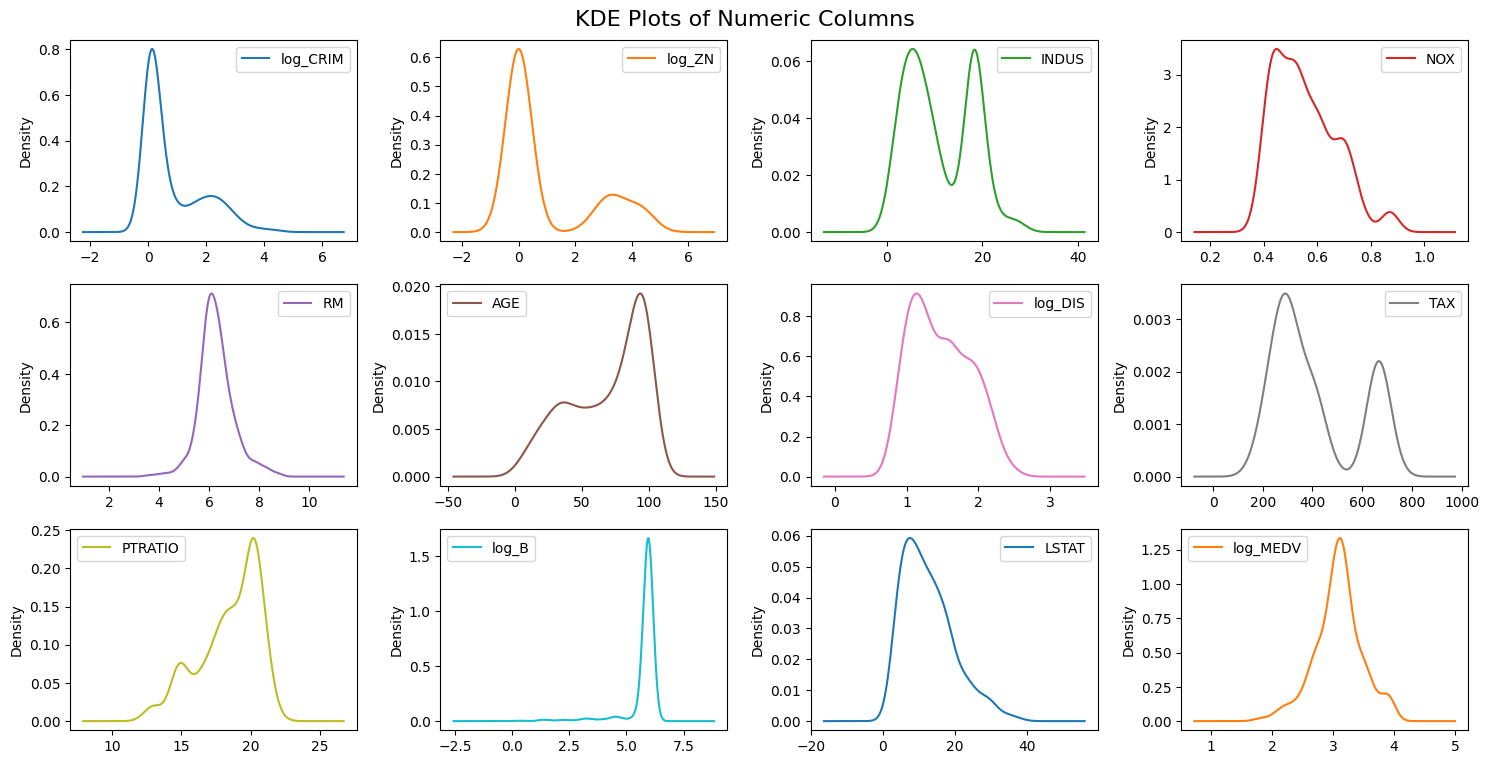

In [81]:
show_dist(df_tran,log_numeric_col)

In [82]:
df_tran[log_numeric_col].skew()

log_CRIM    1.269201
log_ZN      1.193451
INDUS       0.295022
NOX         0.729308
RM          0.403612
AGE        -0.598963
log_DIS     0.331561
TAX         0.669956
PTRATIO    -0.802325
log_B      -4.459061
LSTAT       0.906460
log_MEDV   -0.241244
dtype: float64

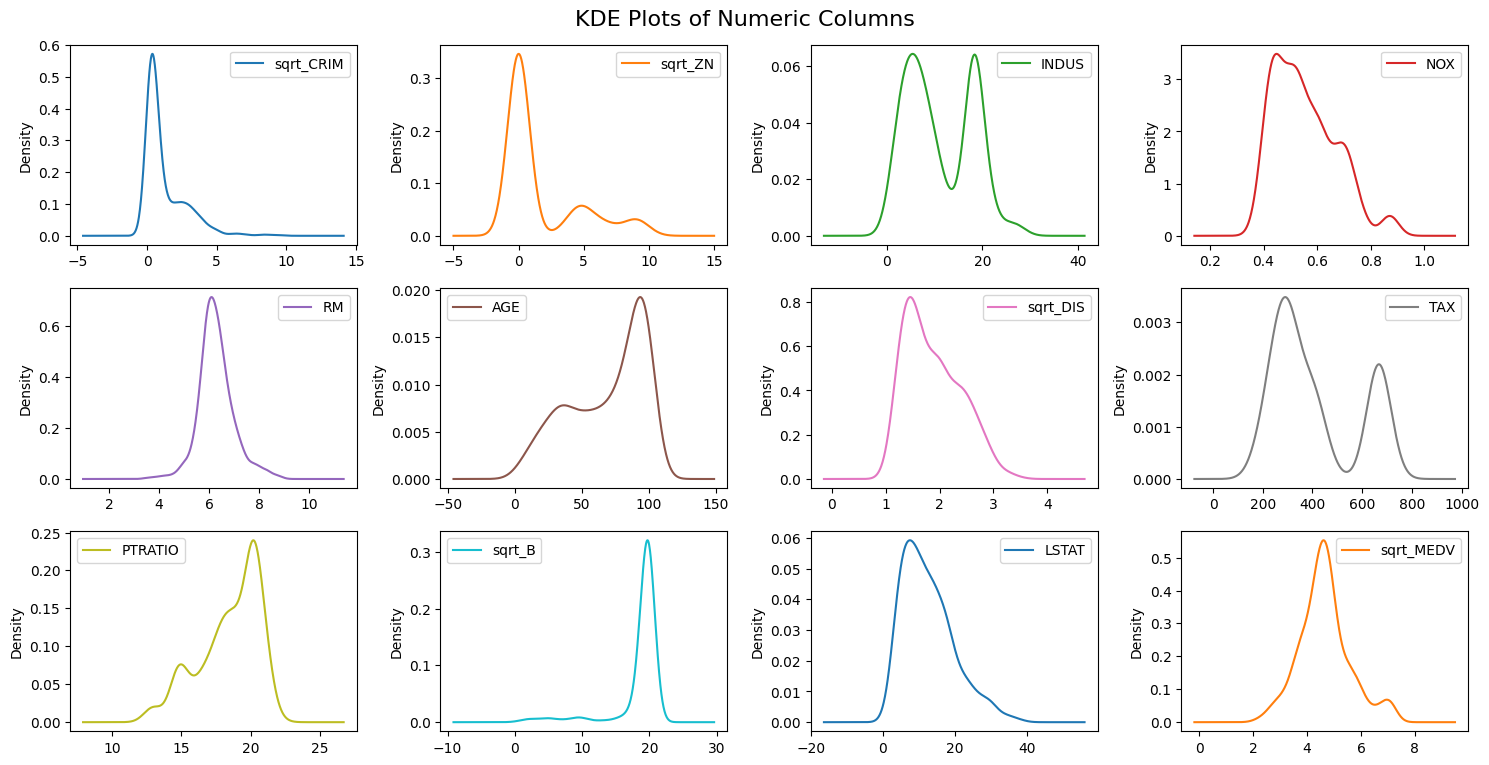

In [83]:
show_dist(df_tran,sqrt_numeric_col)

In [84]:
df_tran[sqrt_numeric_col].skew()

sqrt_CRIM    2.024382
sqrt_ZN      1.476293
INDUS        0.295022
NOX          0.729308
RM           0.403612
AGE         -0.598963
sqrt_DIS     0.564424
TAX          0.669956
PTRATIO     -0.802325
sqrt_B      -3.356219
LSTAT        0.906460
sqrt_MEDV    0.438935
dtype: float64

In [87]:
outlier_percent(df_tran,numeric_col)

sqrt_MEDV : 8.30%
B : 15.22%
NOX : 0.00%
PTRATIO : 2.96%
LSTAT : 1.38%
log_CRIM : 1.19%
ZN : 13.44%
log_MEDV : 8.70%
sqrt_ZN : 5.73%
INDUS : 0.00%
RM : 5.93%
DIS : 0.99%
log_ZN : 0.00%
log_B : 15.42%
MEDV : 7.91%
sqrt_B : 15.42%
AGE : 0.00%
sqrt_DIS : 0.00%
sqrt_CRIM : 3.75%
TAX : 0.00%
CRIM : 13.04%
log_DIS : 0.00%


Text(0.5, 1.0, 'Correlation Matrix')

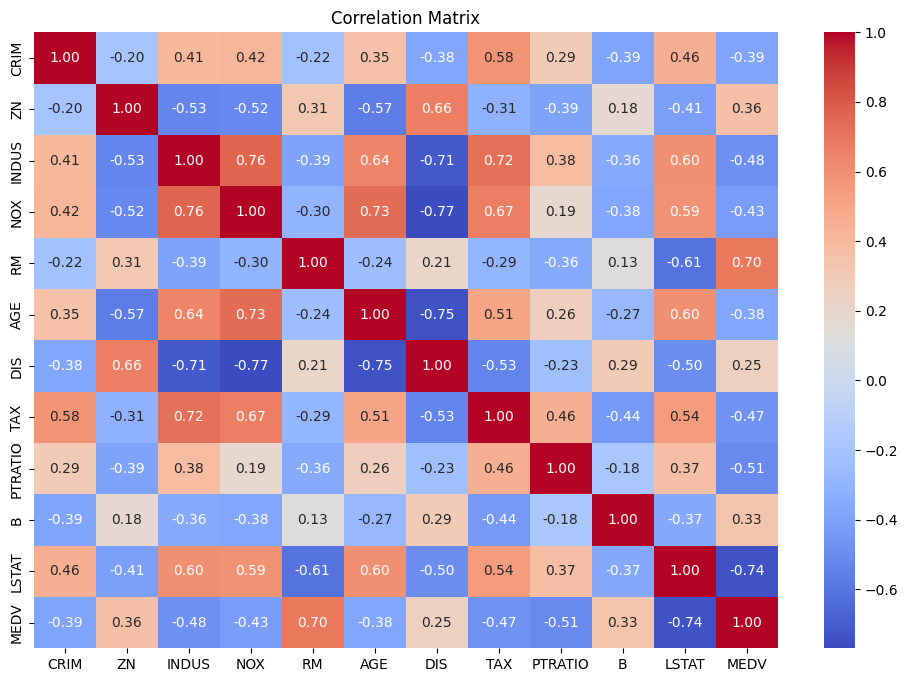

In [88]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_tran[og_numeric_col].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')


In [94]:
scaler = StandardScaler()
df_scaled = df_tran.copy()
df_scaled[numeric_col] = scaler.fit_transform(df_scaled[numeric_col])

In [95]:
df_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   CRIM       506 non-null    float64
 1   ZN         506 non-null    float64
 2   INDUS      506 non-null    float64
 3   CHAS       506 non-null    int64  
 4   NOX        506 non-null    float64
 5   RM         506 non-null    float64
 6   AGE        506 non-null    float64
 7   DIS        506 non-null    float64
 8   RAD        506 non-null    int64  
 9   TAX        506 non-null    float64
 10  PTRATIO    506 non-null    float64
 11  B          506 non-null    float64
 12  LSTAT      506 non-null    float64
 13  MEDV       506 non-null    float64
 14  log_CRIM   506 non-null    float64
 15  sqrt_CRIM  506 non-null    float64
 16  log_ZN     506 non-null    float64
 17  sqrt_ZN    506 non-null    float64
 18  log_DIS    506 non-null    float64
 19  sqrt_DIS   506 non-null    float64
 20  log_B     

In [96]:
def evaluate(model, X_test, y_test, name="Model"):
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    #https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html
    r2 = r2_score(y_test, y_pred)
    print(f"\n{name} Evaluation:")
    print(f"  MSE: {mse:.2f}")
    print(f"  R²: {r2:.2%}")
    return mse, r2

In [97]:
def run_manual_pipeline(X, y, variant_name, k_features=13):
    print(f"\n====== {variant_name.upper()} VARIANT ======")


    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


    selector = SelectKBest(score_func=f_regression, k=k_features)
    X_train_selected = selector.fit_transform(X_train, y_train)
    X_test_selected = selector.transform(X_test)

    selected_features = X.columns[selector.get_support()]
    print(f"Selected Features ({k_features}):", list(selected_features))


    lr = LinearRegression()
    lr_cv = cross_val_score(lr, X_train_selected, y_train, cv=5, scoring='r2')
    lr.fit(X_train_selected, y_train)
    print("Linear Regression CV R2 Mean:", lr_cv.mean())
    evaluate(lr, X_test_selected, y_test, name=f"Linear Regression ({variant_name})")

    # === SGD Regressor Grid Search ===
    sgd = SGDRegressor(random_state=42)
    sgd_param_grid = {
        "loss": ["squared_error", "huber"],
        "penalty": ["l2", "l1", "elasticnet"],
        "alpha": [1e-4, 1e-3, 1e-2],
        "max_iter": [500, 1000],
    }

    sgd_grid = GridSearchCV(sgd, sgd_param_grid, cv=5, scoring="r2", n_jobs=-1)
    sgd_grid.fit(X_train_selected, y_train)

    print("Best SGD Parameters:", sgd_grid.best_params_)
    print("Best SGD CV R2:", sgd_grid.best_score_)
    evaluate(sgd_grid.best_estimator_, X_test_selected, y_test, name=f"SGD Regressor ({variant_name})")


In [100]:
      


target = df_scaled["MEDV"]


# Original
original_cols = og_numeric_col

# Log-transformed
log_cols = log_numeric_col

# Sqrt-transformed
sqrt_cols = sqrt_numeric_col


data_tran={
"original_cols":original_cols,
"log_cols":log_cols,
"sqrt_cols":sqrt_cols,

    
}

In [104]:
for method,cols in data_tran.items():
    #print(method,col)
    run_manual_pipeline(df_scaled[cols], target, variant_name=method,k_features=11)



====== ORIGINAL_COLS VARIANT ======
Selected Features (11): ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'TAX', 'PTRATIO', 'B', 'LSTAT']
Linear Regression CV R2 Mean: 0.7105404459302462

Linear Regression (original_cols) Evaluation:
  MSE: 0.32
  R²: 63.08%
Best SGD Parameters: {'alpha': 0.01, 'loss': 'squared_error', 'max_iter': 500, 'penalty': 'elasticnet'}
Best SGD CV R2: 0.7116506600628709

SGD Regressor (original_cols) Evaluation:
  MSE: 0.32
  R²: 62.80%

====== LOG_COLS VARIANT ======
Selected Features (11): ['log_CRIM', 'log_ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'TAX', 'PTRATIO', 'log_B', 'LSTAT', 'log_MEDV']
Linear Regression CV R2 Mean: 0.9459203760168725

Linear Regression (log_cols) Evaluation:
  MSE: 0.06
  R²: 92.56%
Best SGD Parameters: {'alpha': 0.0001, 'loss': 'squared_error', 'max_iter': 500, 'penalty': 'l1'}
Best SGD CV R2: 0.939237192377352

SGD Regressor (log_cols) Evaluation:
  MSE: 0.07
  R²: 92.28%

====== SQRT_COLS VARIANT ======
Selected Features (11): ['sq